In [1]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [2]:
# allows change in src/ to be reflected in notebook without restarting kernel
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
from metrics import split_chips
from prepare import load_chips

chips = load_chips()
train_chips, val_chips, test_chips = split_chips(chips)

train 608 / val 192 / test 224


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

from model import SmallUNet

DEVICE = "cpu"
EPOCHS = 8
BATCH = 8
LR = 1e-3


class ChipDS(Dataset):
    def __init__(self, chips, augment=False):
        self.chips = chips
        self.augment = augment

    def __len__(self):
        return len(self.chips)

    def __getitem__(self, i):
        c = self.chips[i]
        img = c["img"].astype("float32") / 255.0
        msk = c["msk"].astype("float32")

        if self.augment:
            # .copy() - torch won't take negative-stride views
            if np.random.rand() > 0.5:
                img, msk = img[:, :, ::-1].copy(), msk[:, ::-1].copy()
            if np.random.rand() > 0.5:
                img, msk = img[:, ::-1, :].copy(), msk[::-1, :].copy()

        return torch.from_numpy(img), torch.from_numpy(msk).unsqueeze(0)


def train(train_chips, val_chips, epochs=EPOCHS):
    model = SmallUNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = torch.nn.BCEWithLogitsLoss()

    tl = DataLoader(ChipDS(train_chips, augment=True), batch_size=BATCH, shuffle=True)
    vl = DataLoader(ChipDS(val_chips), batch_size=BATCH)

    history = []
    best_iou = 0.0

    for ep in range(epochs):
        model.train()
        running = 0.0
        for x, y in tqdm(tl, desc=f"epoch {ep + 1}/{epochs}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(x), y)
            loss.backward()
            opt.step()
            running += loss.item()

        model.eval()
        inter = union = 0.0
        with torch.no_grad():
            for x, y in vl:
                p = (torch.sigmoid(model(x.to(DEVICE))) > 0.5).float().cpu()
                inter += (p * y).sum().item()
                union += ((p + y) > 0).float().sum().item()
        iou = inter / (union + 1e-9)

        history.append({"epoch": ep + 1, "loss": running / len(tl), "val_iou": iou})
        print(f"epoch {ep + 1}  loss {running / len(tl):.4f}  val IoU {iou:.3f}")

        # keep the best epoch, not the last
        if iou > best_iou:
            best_iou = iou
            torch.save(model.state_dict(), config.MODEL_PATH)

    return history, best_iou

In [6]:
import time

t0 = time.time()
train(train_chips[:100], val_chips[:20], epochs=2)
print(f"{(time.time() - t0) / 2:.0f} s per epoch on 100 chips")
print(f"projected full epoch: {(time.time() - t0) / 2 * len(train_chips) / 100 / 60:.1f} min")

epoch 1/2:   0%|          | 0/13 [00:00<?, ?it/s]

epoch 1  loss 0.4497  val IoU 0.035


epoch 2/2:   0%|          | 0/13 [00:00<?, ?it/s]

epoch 2  loss 0.3728  val IoU 0.517
6 s per epoch on 100 chips
projected full epoch: 0.6 min


In [7]:
history, best_iou = train(train_chips, val_chips)

epoch 1/8:   0%|          | 0/76 [00:00<?, ?it/s]

epoch 1  loss 0.4668  val IoU 0.589


epoch 2/8:   0%|          | 0/76 [00:00<?, ?it/s]

epoch 2  loss 0.3419  val IoU 0.590


epoch 3/8:   0%|          | 0/76 [00:00<?, ?it/s]

...

epoch 6  loss 0.2473  val IoU 0.548


epoch 7/8:   0%|          | 0/76 [00:00<?, ?it/s]

epoch 7  loss 0.2413  val IoU 0.574


epoch 8/8:   0%|          | 0/76 [00:00<?, ?it/s]

epoch 8  loss 0.2343  val IoU 0.584


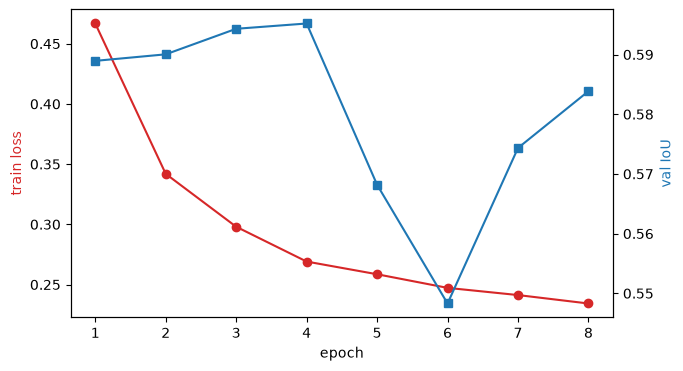

In [8]:
epochs = [h["epoch"] for h in history]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, [h["loss"] for h in history], "o-", color="tab:red")
ax1.set_xlabel("epoch")
ax1.set_ylabel("train loss", color="tab:red")

ax2 = ax1.twinx()
ax2.plot(epochs, [h["val_iou"] for h in history], "s-", color="tab:blue")
ax2.set_ylabel("val IoU", color="tab:blue")

plt.savefig(config.FIGURES / "03_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()